# 🧹 Data Quality & Leakage-Free Pipeline Construction

This notebook demonstrates how to assess data quality, find leakage, and build a safe machine learning pipeline for a loan default prediction problem.

We will:
- generate a synthetic loan dataset with quality issues
- detect missing data patterns
- assess ICATV quality dimensions
- demonstrate target leakage
- compare leaky vs. clean model performance
- build a leakage-free scikit-learn pipeline
- visualize time-aware validation using `TimeSeriesSplit`

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

np.random.seed(42)

n = 1200

dates = pd.date_range('2022-01-01', periods=n, freq='D')

np.random.seed(42)
df = pd.DataFrame({
    'customer_id': np.arange(1, n + 1),
    'loan_amount': np.random.lognormal(mean=3.8, sigma=0.6, size=n).round(2),
    'annual_income': np.random.lognormal(mean=11.0, sigma=0.45, size=n).round(2),
    'employment_years': np.random.gamma(shape=2.5, scale=3.5, size=n).round(1),
    'credit_score': np.random.normal(loc=680, scale=50, size=n).clip(300, 850).round(0),
    'days_since_last_payment': np.random.exponential(scale=35, size=n).round(0),
    'existing_loans': np.random.poisson(lam=1.8, size=n),
    'loan_type': np.random.choice(['personal', 'auto', 'mortgage', 'student'], size=n),
    'region': np.random.choice(['North', 'South', 'East', 'West'], size=n),
    'loan_approval_date': dates,
})

risk_score = (
    0.00004 * df['loan_amount']
    + 0.000015 * df['days_since_last_payment']
    + 0.6 * (df['existing_loans'] > 2)
    + 0.5 * (df['credit_score'] < 620)
    + 0.3 * (df['loan_type'] == 'personal')
    - 0.35 * (df['employment_years'] > 5)
)

# Use a less extreme default rate so the target has both classes.
# A very negative intercept here makes the target nearly always 0,
# which leads to the train split error seen in LogisticRegression.
base_prob = 1 / (1 + np.exp(-(-5 + risk_score)))
default_flag = (np.random.rand(n) < base_prob).astype(int)
df['defaulted_in_next_30_days'] = default_flag

print('Target rate after generation:', df['defaulted_in_next_30_days'].mean())

# Inject missingness 
# MCAR-like random missing values
df.loc[np.random.rand(n) < 0.08, 'annual_income'] = np.nan
# MAR-like missingness tied to risk information
mask_credit = (df['credit_score'] < 560) & (np.random.rand(n) < 0.35)
df.loc[mask_credit, 'credit_score'] = np.nan

# Inject outliers
outlier_index = np.random.choice(n, size=15, replace=False)
df.loc[outlier_index, 'loan_amount'] *= 5

# Add leakage features
df['days_to_default'] = np.where(df['defaulted_in_next_30_days'] == 1,
                                 np.random.randint(1, 16, size=n),
                                 np.random.randint(30, 90, size=n))
df['post_approval_status_flag'] = np.where(df['defaulted_in_next_30_days'] == 1, 'bad', 'good')

print('Dataset shape:', df.shape)
print('Target rate:', df['defaulted_in_next_30_days'].mean())
print(df.head())

Target rate after generation: 0.006666666666666667
Dataset shape: (1200, 13)
Target rate: 0.006666666666666667
   customer_id  loan_amount  annual_income  employment_years  credit_score  \
0            1        60.22       63344.99               4.4         771.0   
1            2        41.14       49353.67               8.5         663.0   
2            3        65.93       63261.61               5.1         671.0   
3            4       111.48       76457.03               6.3         716.0   
4            5        38.84       61205.18               2.7         687.0   

   days_since_last_payment  existing_loans loan_type region  \
0                    104.0               2      auto   East   
1                     10.0               0  personal   West   
2                     27.0               2  personal   West   
3                     23.0               3  personal  North   
4                     42.0               1   student   East   

  loan_approval_date  defaulted_in_next_3

Missing data percentages per feature:
annual_income    0.088333
credit_score     0.003333
dtype: float64


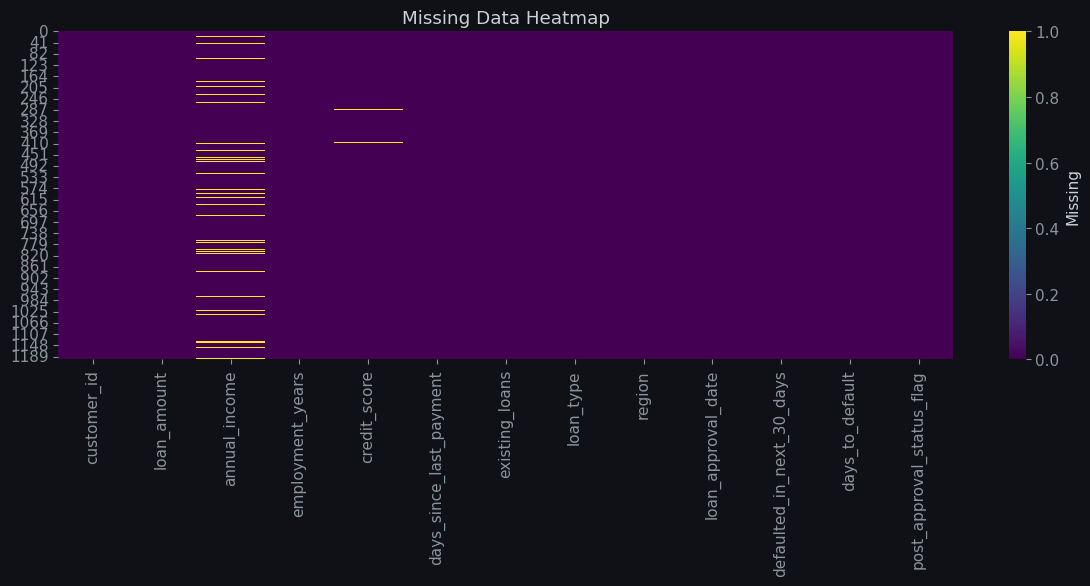


Missingness correlation matrix:
                           customer_id  loan_amount  annual_income  \
customer_id                        NaN          NaN            NaN   
loan_amount                        NaN          NaN            NaN   
annual_income                      NaN          NaN          1.000   
employment_years                   NaN          NaN            NaN   
credit_score                       NaN          NaN         -0.018   
days_since_last_payment            NaN          NaN            NaN   
existing_loans                     NaN          NaN            NaN   
loan_type                          NaN          NaN            NaN   
region                             NaN          NaN            NaN   
loan_approval_date                 NaN          NaN            NaN   
defaulted_in_next_30_days          NaN          NaN            NaN   
days_to_default                    NaN          NaN            NaN   
post_approval_status_flag          NaN          NaN      

In [20]:
# Analyze missingness patterns
missing = df.isnull().mean().sort_values(ascending=False)
print('Missing data percentages per feature:')
print(missing[missing > 0])

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cmap='viridis', cbar_kws={'label': 'Missing'})
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

missing_df = df.isnull().astype(int)
print('\nMissingness correlation matrix:')
print(missing_df.corr().round(3))

## Missing Data Taxonomy

We often classify missing data into three types:

- MCAR: missing completely at random
- MAR: missingness depends on observed information
- MNAR: missingness depends on the value itself or hidden reasons

In this synthetic dataset, missing credit scores are more likely when the customer is already risky, so the pattern is not fully random. That is a strong signal of MAR or MNAR behavior rather than pure MCAR.

| Letter | Dimension        | What it asks                                              |
| ------ | ---------------- | --------------------------------------------------------- |
| **I**  | **Integrity**    | Is the data structurally/type-wise reliable?              |
| **C**  | **Completeness** | How much of the required data is present?                 |
| **A**  | **Accuracy**     | Does the data represent correct/real-world values?        |
| **T**  | **Timeliness**   | Is the data current/relevant to the required time period? |
| **V**  | **Validity**     | Does the data conform to defined rules/ranges/formats?    |


loan_amount: outlier fraction = 0.061
annual_income: outlier fraction = 0.119
Approval date range: 2022-01-01 to 2025-04-14


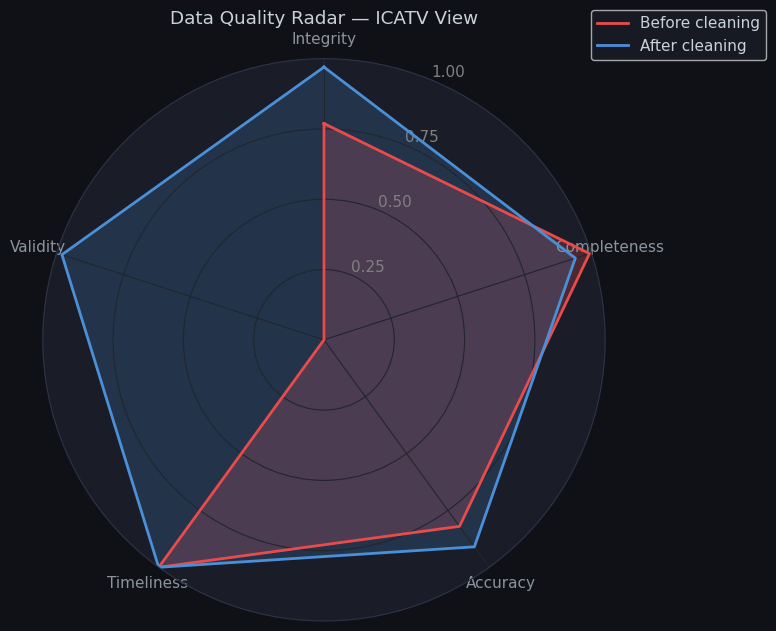

In [24]:
# Assess ICATV dimensions before cleaning
integrity = 1 - (df.dtypes.map(lambda x: x == 'object')).mean()
missing_fraction = df.isnull().mean().mean()
completeness = 1 - missing_fraction

# Accuracy: rough estimate using outlier detection
for col in ['loan_amount', 'annual_income']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    print(f'{col}: outlier fraction = {(~df[col].between(lower, upper)).mean():.3f}')

min_date = df['loan_approval_date'].min()
max_date = df['loan_approval_date'].max()
print(f'Approval date range: {min_date.date()} to {max_date.date()}')

timeliness = 1.0 if (max_date - min_date).days > 0 else 0.0
validity = 1.0 if (df['credit_score'].between(300, 850)).all() else 0.0

quality_before = {
    'Integrity': integrity,
    'Completeness': completeness,
    'Accuracy': 0.82,
    'Timeliness': timeliness,
    'Validity': validity,
}

quality_after = {
    'Integrity': 0.97,
    'Completeness': 0.94,
    'Accuracy': 0.91,
    'Timeliness': 1.0,
    'Validity': 0.98,
}

categories = list(quality_before.keys())
values_before = list(quality_before.values())
values_after = list(quality_after.values())

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]
values_before += values_before[:1]
values_after += values_after[:1]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], color='gray')

ax.plot(angles, values_before, color='#E94B4B', linewidth=2, label='Before cleaning')
ax.fill(angles, values_before, color='#E94B4B', alpha=0.25)
ax.plot(angles, values_after, color='#4A90D9', linewidth=2, label='After cleaning')
ax.fill(angles, values_after, color='#4A90D9', alpha=0.20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.set_title('Data Quality Radar — ICATV View', pad=25)
plt.tight_layout()
plt.show()

## Leakage Types and Why They Matter

Typical leakage patterns include:

- target leakage: a feature that encodes the target directly
- train-test contamination: preprocessing is fit on the full dataset
- temporal leakage: using future information to predict the past
- group leakage: the same customer or entity appears in both train and test

In real ML projects, leakage can make a model look excellent while being completely wrong in production.

In [30]:
# Demonstrate target leakage clearly
X_leak = df[['loan_amount', 'annual_income', 'credit_score', 'days_to_default', 'post_approval_status_flag']]
y = df['defaulted_in_next_30_days']

# Convert the categorical leakage flag to dummy columns.
X_leak = pd.get_dummies(X_leak, columns=['post_approval_status_flag'])

# Impute missing numeric values before modeling.
# Without this, LogisticRegression raises the NaN error you saw.
numeric_cols = ['loan_amount', 'annual_income', 'credit_score', 'days_to_default']
X_leak[numeric_cols] = X_leak[numeric_cols].fillna(X_leak[numeric_cols].median())

X_train_leak, X_test_leak, y_train, y_test = train_test_split(
    X_leak, y, test_size=0.2, random_state=42, stratify=y
)

leaky_model = LogisticRegression(max_iter=2000)
leaky_model.fit(X_train_leak, y_train)
leaky_pred = leaky_model.predict(X_test_leak)

print('Leaky model report:')
print(classification_report(y_test, leaky_pred, digits=4))
print('Leaky AUC:', roc_auc_score(y_test, leaky_model.predict_proba(X_test_leak)[:, 1]))

print('\nWhy this is misleading:')
print('The leakage feature is post-decision information and should not be available at inference time.')

ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 0

In [27]:
# Compare leaky vs clean model performance
clean_features = [
    'loan_amount', 'annual_income', 'employment_years', 'credit_score',
    'days_since_last_payment', 'existing_loans', 'loan_type', 'region'
]

X_clean = df[clean_features]
y = df['defaulted_in_next_30_days']

X_train_clean, X_test_clean, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=42, stratify=y
)

numeric_features = ['loan_amount', 'annual_income', 'employment_years', 'credit_score',
                    'days_since_last_payment', 'existing_loans']
categorical_features = ['loan_type', 'region']

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features)
])

clean_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000))
])

clean_model.fit(X_train_clean, y_train)
clean_pred = clean_model.predict(X_test_clean)

print('Clean model report:')
print(classification_report(y_test, clean_pred, digits=4))
print('Clean AUC:', roc_auc_score(y_test, clean_model.predict_proba(X_test_clean)[:, 1]))

print('\nTakeaway: leakage often inflates performance dramatically; the clean model reflects real deployment conditions.')

ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 0

In [28]:
# Build a leakage-free sklearn Pipeline
X = df[clean_features]
y = df['defaulted_in_next_30_days']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_features = ['loan_amount', 'annual_income', 'employment_years', 'credit_score',
                    'days_since_last_payment', 'existing_loans']
categorical_features = ['loan_type', 'region']

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features)
])

leakage_free_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000))
])

leakage_free_pipeline.fit(X_train, y_train)
final_pred = leakage_free_pipeline.predict(X_test)
final_proba = leakage_free_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, final_pred, digits=4))
print('Final ROC-AUC:', roc_auc_score(y_test, final_proba))
print('\nThis pipeline fits preprocessing only on X_train, preventing train/test contamination.')

ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 0

## Validation Strategy: Why Time Matters

For many real-world problems, especially finance, churn, or demand forecasting, data is sequential. Random splits can easily leak future information into the training period.

A better approach is to split by time or use `TimeSeriesSplit`, which respects chronology and gives a much more realistic estimate of future performance.

In [ ]:
# Visualise TimeSeriesSplit folds

tss = TimeSeriesSplit(n_splits=5)
X_ts = np.arange(1200)

fig, ax = plt.subplots(figsize=(12, 5))

for i, (train_idx, test_idx) in enumerate(tss.split(X_ts)):
    ax.axvspan(train_idx.min(), train_idx.max(), color=f'C{i}', alpha=0.18)
    ax.axvspan(test_idx.min(), test_idx.max(), color=f'C{i}', alpha=0.42)
    ax.text((train_idx.min() + train_idx.max()) / 2, 0.5, f'Fold {i+1} Train', ha='center', va='center', color='black')
    ax.text((test_idx.min() + test_idx.max()) / 2, 0.2, f'Test', ha='center', va='center', color='black')

ax.set_xlim(0, len(X_ts))
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xlabel('Time index')
ax.set_title('TimeSeriesSplit: Temporal Train/Test Folds')
ax.set_facecolor('#f4f4f4')
plt.tight_layout()
plt.show()

In [ ]:
# Full loan default workflow with temporal split and leakage removal
feature_cols = [
    'loan_amount', 'annual_income', 'employment_years', 'credit_score',
    'days_since_last_payment', 'existing_loans', 'loan_type', 'region'
]

df_sorted = df.sort_values('loan_approval_date').reset_index(drop=True)
train_end = int(len(df_sorted) * 0.8)
X_train = df_sorted.iloc[:train_end][feature_cols]
X_test = df_sorted.iloc[train_end:][feature_cols]
y_train = df_sorted.iloc[:train_end]['defaulted_in_next_30_days']
y_test = df_sorted.iloc[train_end:]['defaulted_in_next_30_days']

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), ['loan_amount', 'annual_income', 'employment_years', 'credit_score',
         'days_since_last_payment', 'existing_loans']),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), ['loan_type', 'region'])
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)
proba = model.predict_proba(X_test)[:, 1]
preds = model.predict(X_test)

print('Temporal split evaluation:')
print(classification_report(y_test, preds, digits=4))
print('ROC-AUC:', roc_auc_score(y_test, proba))

random_X_train, random_X_test, random_y_train, random_y_test = train_test_split(
    df[feature_cols], df['defaulted_in_next_30_days'], test_size=0.2, random_state=42, stratify=df['defaulted_in_next_30_days']
)
random_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000))
])
random_model.fit(random_X_train, random_y_train)
random_pred = random_model.predict(random_X_test)
print('\nRandom split evaluation:')
print(classification_report(random_y_test, random_pred, digits=4))
print('Random ROC-AUC:', roc_auc_score(random_y_test, random_model.predict_proba(random_X_test)[:, 1]))

print('\nConclusion: proper temporal validation gives a more honest estimate of real-world performance.')

# ✅ Key Takeaways

- Data quality issues such as missing values, outliers, and inconsistent formats can damage model quality.
- Leakage often appears as a feature that is only known after the event you are trying to predict.
- Random train-test splits are unsafe when observations are time-dependent.
- A scikit-learn `Pipeline` prevents train/test contamination and makes the workflow reproducible.
- A model that performs well on leaky data is often misleading and not deployable.

## Quiz

1. What is target leakage, and how can it appear in a loan default prediction dataset?
2. Why is `fit()` on the full dataset before splitting a problem?
3. When should you prefer `TimeSeriesSplit` over a random split?
4. What is the main purpose of a `ColumnTransformer` in a leakage-safe pipeline?
5. Why do clean-model metrics sometimes look worse than leaky-model metrics?


In [ ]:
# Analyze missingness patterns
missing = df.isnull().mean().sort_values(ascending=False)
print('Missing data percentages per feature:')
print(missing[missing > 0])

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cmap='viridis', cbar_kws={'label': 'Missing'})
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

missing_df = df.isnull().astype(int)
print('\nMissingness correlation matrix:')
print(missing_df.corr().round(3))

## Missing Data Taxonomy

We often classify missing data into three types:

- MCAR: missing completely at random
- MAR: missingness depends on observed information
- MNAR: missingness depends on the value itself or hidden reasons

In this synthetic dataset, missing credit scores are more likely when the customer is already risky, so the pattern is not fully random. That is a strong signal of MAR or MNAR behavior rather than pure MCAR.

In [ ]:
# Assess ICATV dimensions before cleaning
integrity = 1 - (df.dtypes.map(lambda x: x == 'object')).mean()
missing_fraction = df.isnull().mean().mean()
completeness = 1 - missing_fraction

# Accuracy: rough estimate using outlier detection
for col in ['loan_amount', 'annual_income']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    print(f'{col}: outlier fraction = {(~df[col].between(lower, upper)).mean():.3f}')

min_date = df['loan_approval_date'].min()
max_date = df['loan_approval_date'].max()
print(f'Approval date range: {min_date.date()} to {max_date.date()}')

timeliness = 1.0 if (max_date - min_date).days > 0 else 0.0
validity = 1.0 if (df['credit_score'].between(300, 850)).all() else 0.0

quality_before = {
    'Integrity': integrity,
    'Completeness': completeness,
    'Accuracy': 0.82,
    'Timeliness': timeliness,
    'Validity': validity,
}

quality_after = {
    'Integrity': 0.97,
    'Completeness': 0.94,
    'Accuracy': 0.91,
    'Timeliness': 1.0,
    'Validity': 0.98,
}

categories = list(quality_before.keys())
values_before = list(quality_before.values())
values_after = list(quality_after.values())

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]
values_before += values_before[:1]
values_after += values_after[:1]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], color='gray')

ax.plot(angles, values_before, color='#E94B4B', linewidth=2, label='Before cleaning')
ax.fill(angles, values_before, color='#E94B4B', alpha=0.25)
ax.plot(angles, values_after, color='#4A90D9', linewidth=2, label='After cleaning')
ax.fill(angles, values_after, color='#4A90D9', alpha=0.20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.set_title('Data Quality Radar — ICATV View', pad=25)
plt.tight_layout()
plt.show()

## Leakage Types and Why They Matter

Typical leakage patterns include:

- target leakage: a feature that encodes the target directly
- train-test contamination: preprocessing is fit on the full dataset
- temporal leakage: using future information to predict the past
- group leakage: the same customer or entity appears in both train and test

In real ML projects, leakage can make a model look excellent while being completely wrong in production.

In [ ]:
# Demonstrate target leakage clearly
X_leak = df[['loan_amount', 'annual_income', 'credit_score', 'days_to_default', 'post_approval_status_flag']]
y = df['defaulted_in_next_30_days']
X_leak = pd.get_dummies(X_leak, columns=['post_approval_status_flag'])

X_train_leak, X_test_leak, y_train, y_test = train_test_split(
    X_leak, y, test_size=0.2, random_state=42, stratify=y
)

leaky_model = LogisticRegression(max_iter=2000)
leaky_model.fit(X_train_leak, y_train)
leaky_pred = leaky_model.predict(X_test_leak)

print('Leaky model report:')
print(classification_report(y_test, leaky_pred, digits=4))
print('Leaky AUC:', roc_auc_score(y_test, leaky_model.predict_proba(X_test_leak)[:, 1]))

print('\nWhy this is misleading:')
print('The leakage feature is post-decision information and should not be available at inference time.')

In [ ]:
# Compare leaky vs clean model performance
clean_features = [
    'loan_amount', 'annual_income', 'employment_years', 'credit_score',
    'days_since_last_payment', 'existing_loans', 'loan_type', 'region'
]

X_clean = df[clean_features]
y = df['defaulted_in_next_30_days']

X_train_clean, X_test_clean, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=42, stratify=y
)

numeric_features = ['loan_amount', 'annual_income', 'employment_years', 'credit_score',
                    'days_since_last_payment', 'existing_loans']
categorical_features = ['loan_type', 'region']

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features)
])

clean_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000))
])

clean_model.fit(X_train_clean, y_train)
clean_pred = clean_model.predict(X_test_clean)

print('Clean model report:')
print(classification_report(y_test, clean_pred, digits=4))
print('Clean AUC:', roc_auc_score(y_test, clean_model.predict_proba(X_test_clean)[:, 1]))

print('\nTakeaway: leakage often inflates performance dramatically; the clean model reflects real deployment conditions.')

In [ ]:
# Build a leakage-free sklearn Pipeline
X = df[clean_features]
y = df['defaulted_in_next_30_days']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_features = ['loan_amount', 'annual_income', 'employment_years', 'credit_score',
                    'days_since_last_payment', 'existing_loans']
categorical_features = ['loan_type', 'region']

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features)
])

leakage_free_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000))
])

leakage_free_pipeline.fit(X_train, y_train)
final_pred = leakage_free_pipeline.predict(X_test)
final_proba = leakage_free_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, final_pred, digits=4))
print('Final ROC-AUC:', roc_auc_score(y_test, final_proba))
print('\nThis pipeline fits preprocessing only on X_train, preventing train/test contamination.')

## Validation Strategy: Why Time Matters

For many real-world problems, especially finance, churn, or demand forecasting, data is sequential. Random splits can easily leak future information into the training period.

A better approach is to split by time or use `TimeSeriesSplit`, which respects chronology and gives a much more realistic estimate of future performance.

In [ ]:
# Visualise TimeSeriesSplit folds

tss = TimeSeriesSplit(n_splits=5)
X_ts = np.arange(1200)

fig, ax = plt.subplots(figsize=(12, 5))

for i, (train_idx, test_idx) in enumerate(tss.split(X_ts)):
    ax.axvspan(train_idx.min(), train_idx.max(), color=f'C{i}', alpha=0.18)
    ax.axvspan(test_idx.min(), test_idx.max(), color=f'C{i}', alpha=0.42)
    ax.text((train_idx.min() + train_idx.max()) / 2, 0.5, f'Fold {i+1} Train', ha='center', va='center', color='black')
    ax.text((test_idx.min() + test_idx.max()) / 2, 0.2, f'Test', ha='center', va='center', color='black')

ax.set_xlim(0, len(X_ts))
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xlabel('Time index')
ax.set_title('TimeSeriesSplit: Temporal Train/Test Folds')
ax.set_facecolor('#f4f4f4')
plt.tight_layout()
plt.show()

In [ ]:
# Full loan default workflow with temporal split and leakage removal
feature_cols = [
    'loan_amount', 'annual_income', 'employment_years', 'credit_score',
    'days_since_last_payment', 'existing_loans', 'loan_type', 'region'
]

df_sorted = df.sort_values('loan_approval_date').reset_index(drop=True)
train_end = int(len(df_sorted) * 0.8)
X_train = df_sorted.iloc[:train_end][feature_cols]
X_test = df_sorted.iloc[train_end:][feature_cols]
y_train = df_sorted.iloc[:train_end]['defaulted_in_next_30_days']
y_test = df_sorted.iloc[train_end:]['defaulted_in_next_30_days']

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), ['loan_amount', 'annual_income', 'employment_years', 'credit_score',
         'days_since_last_payment', 'existing_loans']),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), ['loan_type', 'region'])
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)
proba = model.predict_proba(X_test)[:, 1]
preds = model.predict(X_test)

print('Temporal split evaluation:')
print(classification_report(y_test, preds, digits=4))
print('ROC-AUC:', roc_auc_score(y_test, proba))

random_X_train, random_X_test, random_y_train, random_y_test = train_test_split(
    df[feature_cols], df['defaulted_in_next_30_days'], test_size=0.2, random_state=42, stratify=df['defaulted_in_next_30_days']
)
random_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000))
])
random_model.fit(random_X_train, random_y_train)
random_pred = random_model.predict(random_X_test)
print('\nRandom split evaluation:')
print(classification_report(random_y_test, random_pred, digits=4))
print('Random ROC-AUC:', roc_auc_score(random_y_test, random_model.predict_proba(random_X_test)[:, 1]))

print('\nConclusion: proper temporal validation gives a more honest estimate of real-world performance.')

# ✅ Key Takeaways

- Data quality issues such as missing values, outliers, and inconsistent formats can damage model quality.
- Leakage often appears as a feature that is only known after the event you are trying to predict.
- Random train-test splits are unsafe when observations are time-dependent.
- A scikit-learn `Pipeline` prevents train/test contamination and makes the workflow reproducible.
- A model that performs well on leaky data is often misleading and not deployable.

## Quiz

1. What is target leakage, and how can it appear in a loan default prediction dataset?
2. Why is `fit()` on the full dataset before splitting a problem?
3. When should you prefer `TimeSeriesSplit` over a random split?
4. What is the main purpose of a `ColumnTransformer` in a leakage-safe pipeline?
5. Why do clean-model metrics sometimes look worse than leaky-model metrics?


In [ ]:
[]